In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu, \
    pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.multicomp import MultiComparison
from ydata_profiling import ProfileReport

sns.set_style('darkgrid')

In [2]:
df1 = pd.read_csv('C:/Python/Datasets/ecom_ab.csv')
df2 = pd.read_csv('C:/Python/Datasets/ecom_countries.csv')

Merging two datasets to get more info about countries distribution

In [3]:
df = df1.merge(df2)

Profiling dataset to get overview

In [4]:
ProfileReport(df, title='ProfilingReport')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:03<00:00,  1.62it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**con_treat** and **page** columns stand for the same information but some rows don`t match. Get rid of them

In [5]:
df_clean = df.loc[~((df.con_treat == 'treatment') & (df.page == 'old_page') | (df.con_treat == 'control') & (df.page == 'new_page'))]

Also drop one of the column. In this case drop **con_treat**

In [6]:
df_clean = df_clean.drop(columns=['con_treat'])

There is also some **user id** that met more than once. Take a look at it

In [7]:
df_clean.id.value_counts()

id
773192    2
679687    1
719014    1
909437    1
905617    1
         ..
751197    1
945152    1
734608    1
697314    1
936923    1
Name: count, Length: 290584, dtype: int64

In [8]:
df_clean.loc[df_clean.id == 773192]

,id,time,page,converted,country
1899,773192,37:58.8,new_page,0,US
2893,773192,55:59.6,new_page,0,US


Both times id is in test group, so we may take the average time spent as metric

In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290585 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         290585 non-null  int64 
 1   time       290585 non-null  object
 2   page       290585 non-null  object
 3   converted  290585 non-null  int64 
 4   country    290585 non-null  object
dtypes: int64(2), object(3)
memory usage: 13.3+ MB


Switch columns to more appropriate type. Assume that time is measured in **minutes:seconds.miliseconds**. Drop off miliseconds

In [10]:
df_clean.country = df_clean.country.astype('category') # switch coutry to category type as we got only 3 unique values
df_clean.time = df_clean.time.str[:-2] # drop off miliseconds
df_clean.time = pd.to_timedelta('00:' + df_clean['time']).dt.total_seconds().astype(int) # switch MM:SS to total seconds
df_clean.converted = df_clean.converted.astype('bool') # switch converted to bool type

In [11]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290585 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   id         290585 non-null  int64   
 1   time       290585 non-null  int64   
 2   page       290585 non-null  object  
 3   converted  290585 non-null  bool    
 4   country    290585 non-null  category
dtypes: bool(1), category(1), int64(2), object(1)
memory usage: 9.4+ MB


Compute mean time spent for one duplicated user

In [12]:
meantime = df_clean.loc[df_clean.id == 773192].time.mean().astype('int64')
df_clean = df_clean.drop_duplicates(subset='id')
df_clean.loc[df_clean.id == 773192, 'time'] = meantime

In [13]:
df_clean.id.duplicated().sum()

np.int64(0)

No more duplicates

In [14]:
df_clean

,id,time,page,converted,country
0,851104,708,old_page,False,US
1,804228,105,old_page,False,US
2,661590,3306,new_page,False,US
3,853541,1683,new_page,False,US
4,864975,3146,old_page,True,US
...,...,...,...,...,...
294473,751197,1718,old_page,False,US
294474,945152,3117,old_page,False,US
294475,734608,2703,old_page,False,US
294476,697314,1229,old_page,False,US


Text(0, 0.5, 'Countries')

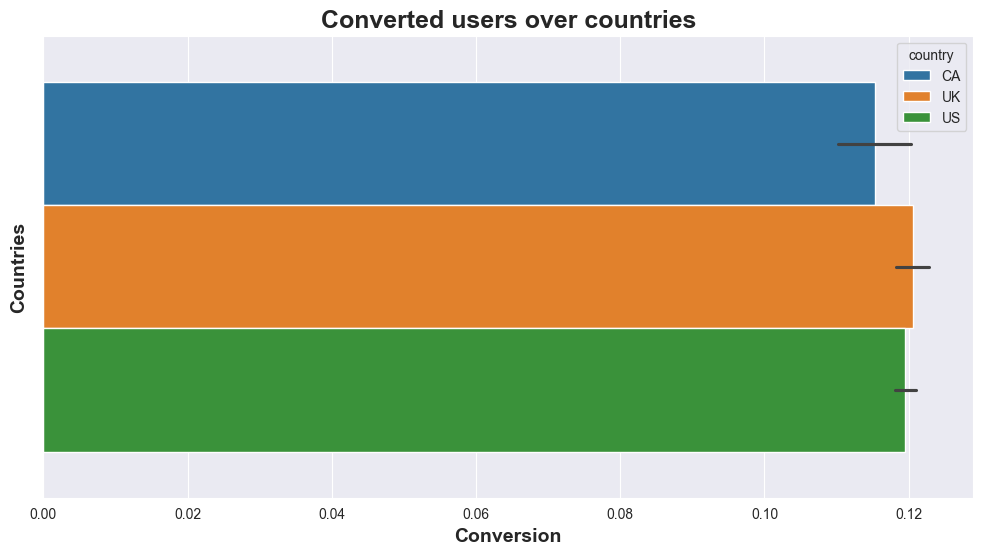

In [23]:
plt.subplots(figsize=(12,6))
sns.barplot(data=df_clean, x='converted', hue='country')
plt.title('Converted users over countries', fontsize=18, fontweight='demi')
plt.xlabel('Conversion', fontsize=14, fontweight='demi')
plt.ylabel('Countries', fontsize=14, fontweight='demi')

Proportions z_test

In [29]:
nobs = df_clean.groupby(by='page', as_index=False).id.count()
nobs

,page,id
0,new_page,145310
1,old_page,145274


In [33]:
count = df_clean.loc[df_clean.converted==True]

In [28]:
old = df_clean.loc[df_clean.page == 'old_page', 'converted']
new = df_clean.loc[df_clean.page == 'new_page', 'converted']

In [46]:
z_stat, p_value = proportions_ztest(count=[count.loc[count.page == 'old_page'].shape[0], count.loc[count.page == 'new_page'].shape[0]],
                  nobs=[nobs.loc[nobs.page == 'old_page', 'id'].iloc[0], nobs.loc[nobs.page == 'new_page', 'id'].iloc[0]],
                  alternative='two-sided'
                  )

In [47]:
print('Z_stat:', z_stat)
print('p-value:', p_value)

Z_stat: 1.3109241984234394
p-value: 0.18988337448195103


No statistical significance